# LUCC Continuous (CLUE) — a synthetic example

This notebook builds and runs a small, fully synthetic land-use-change
scenario with `disslucc`'s continuous (CLUE-like) allocation — no
shapefiles, no real data, just a deterministic `np.random` landscape,
small enough to read and run cell by cell.

For the real validated scenario (Lab1, against the original TerraME
reference), see [`examples/run_lab1_via_executor.py`](https://github.com/DisSModel/disslucc/blob/main/examples/run_lab1_via_executor.py) and
[Validation](../../validation.md) instead — this notebook is for
understanding the mechanics, not for validation.

## The model

Three components, each a real `dissmodel.core.Model` — they connect to
the active `Environment` automatically when constructed, in the order
they're built below:

```
Environment → Demand → Potential → Allocation
```

- **Demand** says how many cells of each class are wanted at each step.
- **Potential** scores, per cell and class, how *suitable* that cell is
  for that class (here: a linear regression over synthetic drivers).
- **Allocation** converts scores + demand into the actual per-cell
  land-use change (CLUE-like: cells compete, demand is matched by
  iteratively correcting the potential with a per-class term).

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dissmodel.core import Environment
from dissmodel.geo import RasterBackend

from disslucc import AllocationClueLike, DemandInline, PotentialLinearRegression
from disslucc.schemas import AllocationSpec, RegressionSpec

## Building a synthetic landscape

A 30×30 raster with two synthetic drivers -- `dist_road` (distance to a
horizontal "road" across the middle row, normalized) and `slope` (a
smooth sum of sinusoids plus a little noise) -- and an initial land-use
state that's mostly `forest`, with a single `urban` seed cell next to
the road.

In [2]:
HEIGHT = WIDTH = 30
LAND_USE_TYPES = ["forest", "agriculture", "urban"]
COMPLEMENTAR_LU = "forest"

rng = np.random.default_rng(42)

road_row = HEIGHT // 2
rows = np.arange(HEIGHT, dtype=np.float32)[:, None]
dist_road = np.repeat(np.abs(rows - road_row), WIDTH, axis=1)
dist_road = dist_road / dist_road.max()

yy, xx = np.mgrid[0:HEIGHT, 0:WIDTH]
slope = (
    np.sin(xx / 4.0) * 0.5 + np.cos(yy / 5.0) * 0.5
    + rng.normal(0, 0.05, size=(HEIGHT, WIDTH))
).astype(np.float32)
slope = (slope - slope.min()) / (slope.max() - slope.min())

backend = RasterBackend(shape=(HEIGHT, WIDTH))
backend.set("dist_road", dist_road.astype(np.float32))
backend.set("slope", slope)

urban = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
urban[road_row, WIDTH // 2] = 1.0  # a single seed cell
agriculture = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
forest = 1.0 - urban - agriculture
backend.set("urban", urban)
backend.set("agriculture", agriculture)
backend.set("forest", forest)

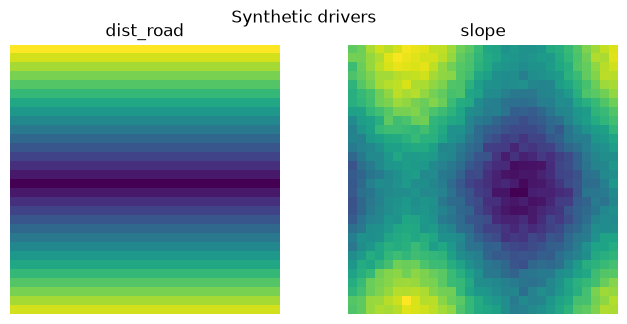

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(dist_road, cmap="viridis"); axes[0].set_title("dist_road"); axes[0].axis("off")
axes[1].imshow(slope, cmap="viridis"); axes[1].set_title("slope"); axes[1].axis("off")
fig.suptitle("Synthetic drivers")
plt.show()

## Demand

How many cells of each class we want at each step -- growing `urban`
and `agriculture` linearly, `forest` is whatever's left (the row sums
must always equal the total cell count, which is what CLUE expects
from a well-formed demand table).

In [4]:
N_STEPS = 8
total = HEIGHT * WIDTH

demand_matrix = []
for step in range(N_STEPS):
    urban_target = 1 + 3 * step
    agri_target = 1 * step
    forest_target = total - urban_target - agri_target
    demand_matrix.append([float(forest_target), float(agri_target), float(urban_target)])

demand_matrix[:3]  # first 3 steps, [forest, agriculture, urban]

[[899.0, 0.0, 1.0], [895.0, 1.0, 4.0], [891.0, 2.0, 7.0]]

## ⚠️ Instantiation order

`Environment` first, then `Demand → Potential → Allocation` -- each
connects to the active environment when constructed, and `Potential`
needs `demand`, `Allocation` needs both `demand` and `potential`.

In [5]:
env = Environment(end_time=N_STEPS - 1)

demand = DemandInline(values=demand_matrix, land_use_types=LAND_USE_TYPES)

potential = PotentialLinearRegression(
    backend=backend,
    demand=demand,
    land_use_types=LAND_USE_TYPES,
    potential_data=[[
        RegressionSpec(const=-0.2, betas={"slope": 0.4}),                     # forest
        RegressionSpec(const=0.4, betas={"dist_road": -0.1, "slope": -0.5}),  # agriculture
        RegressionSpec(const=0.3, betas={"dist_road": -0.6, "slope": -0.3}),  # urban
    ]],
)

allocation = AllocationClueLike(
    backend=backend,
    demand=demand,
    potential=potential,
    land_use_types=LAND_USE_TYPES,
    static={"forest": 0, "agriculture": -1, "urban": -1},
    complementar_lu=COMPLEMENTAR_LU,
    cell_area=1.0,
    max_difference=5.0,
    allocation_data=[
        AllocationSpec(static=0),
        AllocationSpec(static=-1),
        AllocationSpec(static=-1),
    ],
)

## Running the simulation

In [6]:
env.run()

Running from 0 to 7 (duration: 7)


## Result

Each class is a fractional band (`[0, 1]` per cell) -- CLUE allocates
cells to the class with the best score until demand is matched within
`max_difference`, so the sums below won't hit the targets exactly.

In [7]:
print("Area (sum of fractions) per class after", N_STEPS - 1, "steps:")
for lu in LAND_USE_TYPES:
    print(f"  {lu:>12}: {float(backend.get(lu).sum()):8.1f}")

print("\nLast-step demand target vs allocated:")
for i, lu in enumerate(LAND_USE_TYPES):
    target = demand_matrix[-1][i]
    actual = float(backend.get(lu).sum())
    print(f"  {lu:>12}: target={target:8.1f}  allocated={actual:8.1f}  diff={abs(target - actual):6.2f}")

Area (sum of fractions) per class after 7 steps:
        forest:    866.3
   agriculture:     11.3
         urban:     22.3

Last-step demand target vs allocated:
        forest: target=   871.0  allocated=   866.3  diff=  4.67
   agriculture: target=     7.0  allocated=    11.3  diff=  4.35
         urban: target=    22.0  allocated=    22.3  diff=  0.32


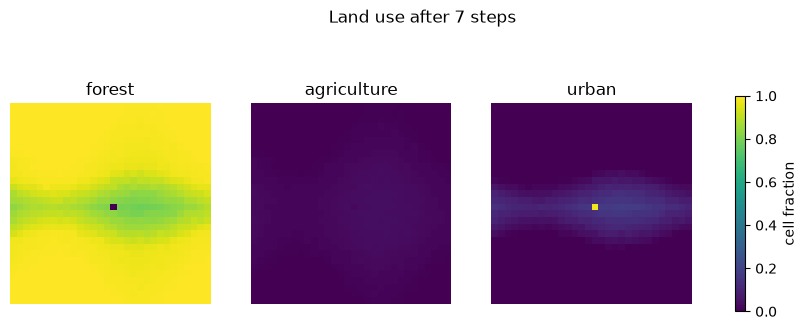

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, lu in zip(axes, LAND_USE_TYPES):
    im = ax.imshow(backend.get(lu), cmap="viridis", vmin=0, vmax=1)
    ax.set_title(lu)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.7, label="cell fraction")
fig.suptitle(f"Land use after {N_STEPS - 1} steps")
plt.show()

## Try it yourself

Go back and experiment:

- Change `N_STEPS` or the demand growth rates for `urban`/`agriculture`
- Move the `urban` seed cell, or add a second one
- Change the `RegressionSpec` coefficients -- e.g. make `agriculture`
  favor flatter areas more strongly (`betas={"slope": -1.0}`)
- Tighten `max_difference` and see how many more steps it takes to
  match demand exactly

For the same model driven by real data and validated against TerraME,
see [`examples/run_lab1_via_executor.py`](https://github.com/DisSModel/disslucc/blob/main/examples/run_lab1_via_executor.py) and
[Validation](../../validation.md). For automatic provenance
(`ModelExecutor`/`ExperimentRecord`, a CLI), see
[API Reference](../../api.md#executors-dissluccexecutors).